# 🔮 04 — Prophet avec COVID comme Holiday
## Modèle Prophet avec grid search des hyperparamètres

Ce notebook utilise Prophet en déclarant la période COVID comme holiday. 3 configurations testées avec différents `holidays_prior_scale`.

## 1. 📦 Imports & Chargement

In [31]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ Imports OK")

✅ Imports OK


In [32]:
# Charger les données (Prophet utilise ds/y)
df = pd.read_csv("prepared_data.csv", index_col=0, parse_dates=True).reset_index()
df = df.rename(columns={"date": "ds", "revenue": "y"})

prophet_train = df[df["ds"].dt.year < 2022].copy()
prophet_test = df[df["ds"].dt.year == 2022].copy()

print(f"✅ Données chargées")
print(f"   Train : {len(prophet_train)} mois → Test : {len(prophet_test)} mois")

✅ Données chargées
   Train : 36 mois → Test : 12 mois


## 2. 🦠 Définition des Holidays COVID

In [33]:
covid_events = []
# COVID sévère
for y, m in [(2020,3),(2020,4),(2020,5),(2020,6)]:
    covid_events.append({"holiday": "covid_severe", "ds": pd.Timestamp(f"{y}-{m:02d}-01"),
                         "lower_window": 0, "upper_window": 0})
# COVID modéré
for y, m in [(2020,7),(2020,8),(2020,9),(2020,10),(2020,11),(2020,12),
             (2021,1),(2021,2),(2021,3),(2021,4),(2021,5),(2021,6)]:
    covid_events.append({"holiday": "covid_moderate", "ds": pd.Timestamp(f"{y}-{m:02d}-01"),
                         "lower_window": 0, "upper_window": 0})
# Noël
for y in range(2018, 2024):
    covid_events.append({"holiday": "christmas", "ds": pd.Timestamp(f"{y}-12-01"),
                         "lower_window": 0, "upper_window": 0})

holidays_df = pd.DataFrame(covid_events)
print(f"✅ {len(holidays_df)} holidays définis (sévère={4}, modéré={12}, noël={6})")
print("   ⚠️ upper_window=0 (pas de fenêtre, données mensuelles)")

✅ 22 holidays définis (sévère=4, modéré=12, noël=6)
   ⚠️ upper_window=0 (pas de fenêtre, données mensuelles)


## 3. 🔮 Prophet Manuel — paramètres fixes

In [34]:
# ── Prophet Manuel ───────────────────────────────────────
print("🔮 Prophet Manuel")
print("   holidays_prior_scale=5.0, seasonality_mode=additive")
print("   changepoint_prior_scale=0.03, seasonality_prior_scale=8.0")

prophet_model = Prophet(
    holidays=holidays_df,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",          # ← passage en additif (plus stable)
    changepoint_prior_scale=0.8,
    seasonality_prior_scale=2,
    holidays_prior_scale=0.1,             # ← réduit pour éviter l'overfitting
    interval_width=0.95,
)
prophet_model.add_seasonality(name="monthly", period=30.5, fourier_order=3)

print("\n⏳ Entraînement...")
prophet_model.fit(prophet_train)

# Prévisions
future = prophet_model.make_future_dataframe(periods=12, freq="MS")
forecast = prophet_model.predict(future)

forecast_test = forecast[forecast["ds"].dt.year == 2022].copy()
y_pred = forecast_test.set_index("ds")["yhat"].clip(lower=0)
y_true = prophet_test.set_index("ds")["y"]

common_idx = y_true.index.intersection(y_pred.index)
y_pred = y_pred[common_idx]
y_true = y_true[common_idx]

mape_val = np.mean(np.abs((y_true.values - y_pred.values) / y_true.values)) * 100
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"\n📊 Prophet")
print(f"   MAE  : {mae:>12,.0f} €")
print(f"   RMSE : {rmse:>12,.0f} €")
print(f"   MAPE : {mape_val:>11.2f} %")
print(f"   R²   : {r2:>11.4f}")

18:23:40 - cmdstanpy - INFO - Chain [1] start processing


🔮 Prophet Manuel
   holidays_prior_scale=5.0, seasonality_mode=additive
   changepoint_prior_scale=0.03, seasonality_prior_scale=8.0

⏳ Entraînement...


18:24:01 - cmdstanpy - INFO - Chain [1] done processing



📊 Prophet
   MAE  :   15,813,856 €
   RMSE :   17,803,515 €
   MAPE :       17.01 %
   R²   :     -0.4197


## 4. 📊 Visualisation & Sauvegarde

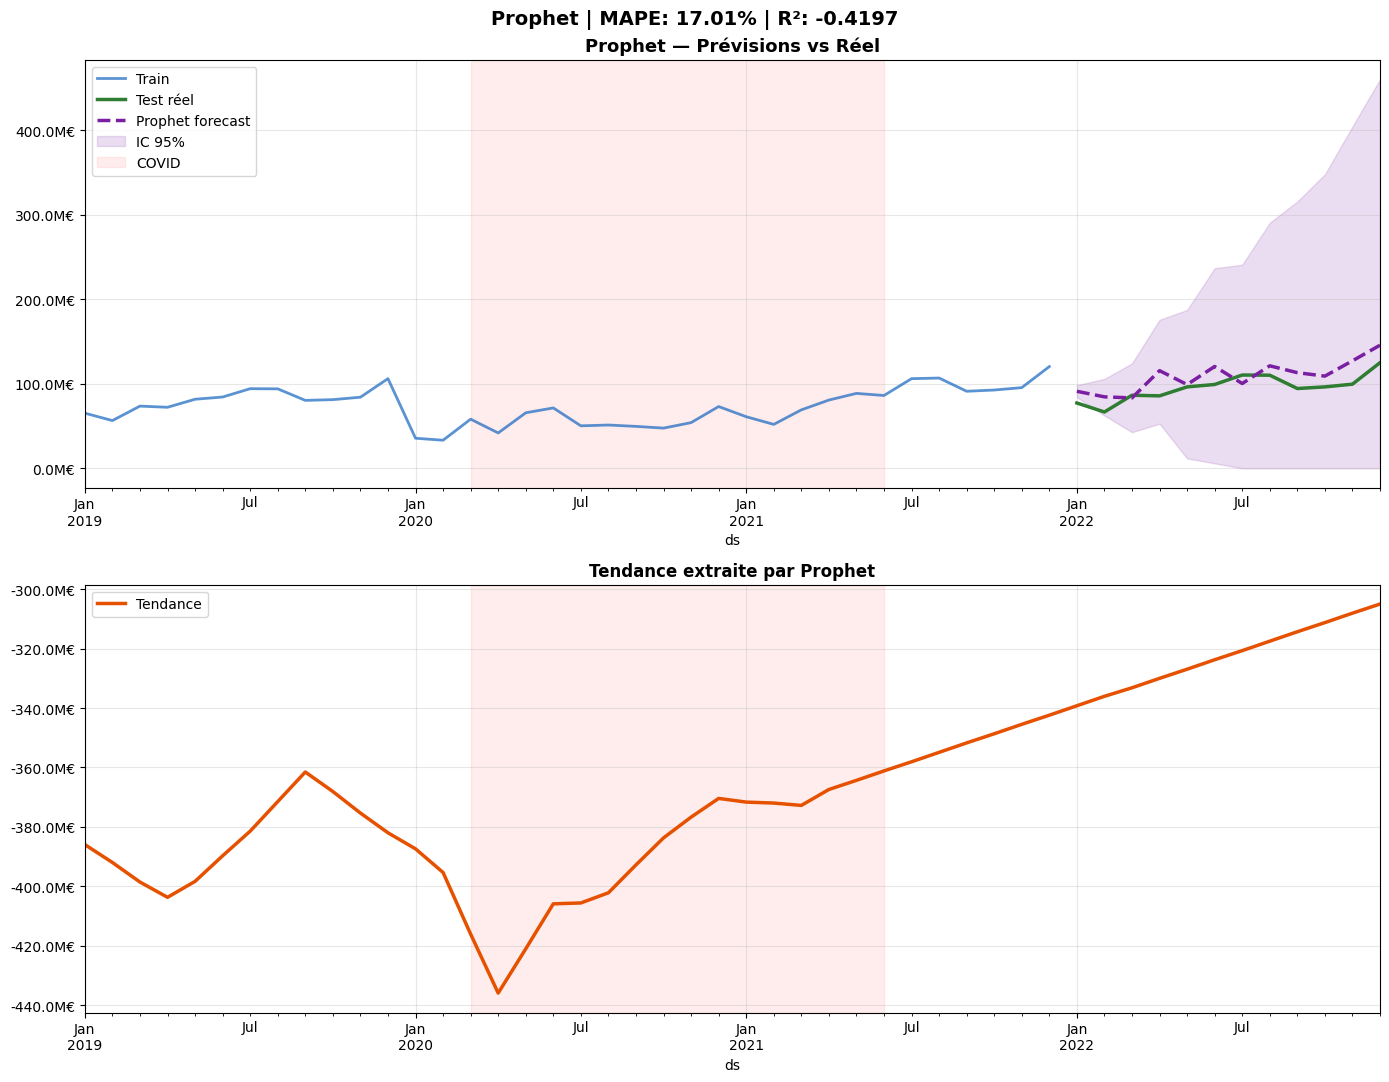

💾 Graphique → modele4_prophet.png


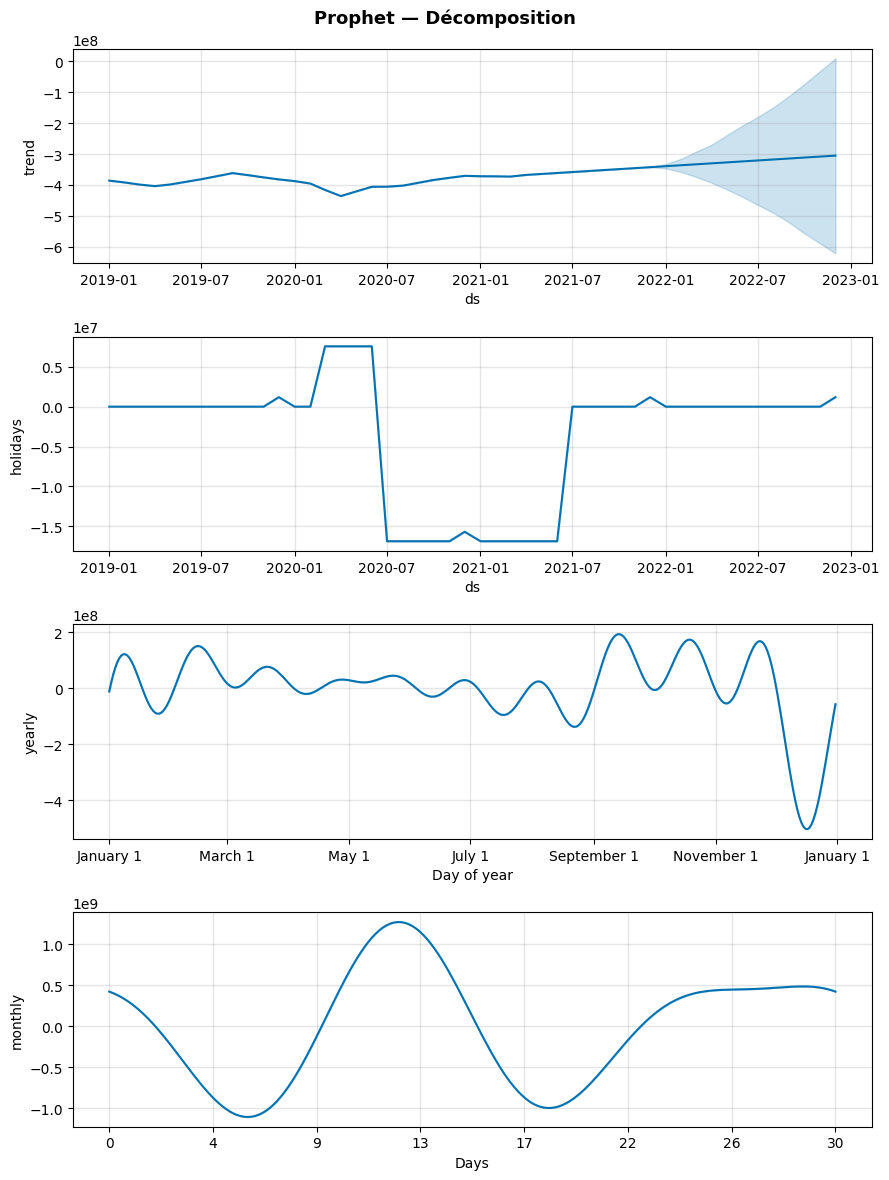

💾 Composantes → modele4_prophet_components.png
💾 Prédictions → predictions_prophet.csv


In [35]:
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

ax = axes[0]
prophet_train.set_index("ds")["y"].plot(ax=ax, label="Train", color="#1565C0", alpha=0.7, linewidth=2)
y_true.plot(ax=ax, label="Test réel", color="#2E7D32", linewidth=2.5)
y_pred.plot(ax=ax, label="Prophet forecast", color="#7B1FA2", linestyle="--", linewidth=2.5)

forecast_test = forecast[forecast["ds"].dt.year == 2022].set_index("ds")
ax.fill_between(forecast_test.index, forecast_test["yhat_lower"].clip(lower=0),
                forecast_test["yhat_upper"], alpha=0.15, color="#7B1FA2", label="IC 95%")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"), alpha=0.07, color="red", label="COVID")
ax.set_title("Prophet — Prévisions vs Réel", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax.legend(); ax.grid(alpha=0.3)

ax2 = axes[1]
trend_full = forecast.set_index("ds")["trend"]
trend_full.plot(ax=ax2, color="#E65100", linewidth=2.5, label="Tendance")
ax2.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"), alpha=0.07, color="red")
ax2.set_title("Tendance extraite par Prophet", fontsize=12, fontweight="bold")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax2.grid(alpha=0.3); ax2.legend()

plt.suptitle(f"Prophet | MAPE: {mape_val:.2f}% | R²: {r2:.4f}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("modele4_prophet.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Graphique → modele4_prophet.png")

# Composantes
fig2 = prophet_model.plot_components(forecast)
fig2.suptitle("Prophet — Décomposition", fontsize=13, fontweight="bold")
plt.tight_layout()
fig2.savefig("modele4_prophet_components.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Composantes → modele4_prophet_components.png")

# Sauvegarder
results_df = pd.DataFrame({"date": y_true.index, "reel": y_true, "prediction": y_pred})
results_df.to_csv("predictions_prophet.csv", index=False)
print("💾 Prédictions → predictions_prophet.csv")